### Can a computer learn if we are going to detect gravitational waves? (Part 2)
 In order to decide if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our **selection effects**.

 In observational astronomy, this is known as **Malmquist bias** and was first formulated in 1922.

 The goal here is to learn the **LIGO detectability** using a neural network: can we predict if a gravitational-wave source will be detected?

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import h5py

In [4]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report

In [6]:
from sklearn.neural_network import MLPClassifier

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
drive_path = "/content/drive/MyDrive/AstroStats/"
file_path = os.path.join(drive_path, "sample_2e7_design_precessing_higherordermodes_3detectors.h5")

In [9]:
# Exploring the datafile categories
names = []
with h5py.File(file_path, 'r') as f:
  for key in f.keys():
    names.append(key)

In [10]:
print(names)

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [11]:
# Extrapolating data
data = []
with h5py.File(file_path, 'r') as f:
  for key in names:
    temp_data = f[key][:]
    data.append(temp_data)

In [12]:
# Creating a dataframe for more visibility
table = pd.DataFrame(np.array(data).T, columns=names)

This dataset contains simulated gravitational-wave signals from merging black holes.

In particular, each source has the following features:
1. **mtot**: the total mass of the binary
2. **q**: the mass ratio
3. **chi1x, chi1y, chi1z, chi2x, chi2y, chi2z**: the components of the black-hole spins in a suitable reference frame
4. **ra, dec**: the location of the source in the sky
5. **iota**: the inclination of the orbital plane
6. **psi**: the polarization angle (gravitational waves have two polarization states much like light)
7. **z**: the redshift

The detectability is defined using the **snr** (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network.

All you need to know now is that we threshold the snr values and assume that LIGO will (not) see a source if snr > 12 (snr < 12).

The resulting 0-1 labels are reported in the **det** attribute in the dataset.

In [13]:
table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0.0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0.0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0.0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0.0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1.0,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0.0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0.0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0.0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0.0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


**Tasks**

- Scale your data appropriately.

- Decide on a testing strategy (a simple test/train split or a CV strategy).

- Decide your optimization metric.

- Write down your network architecture. You can start from a fully connected, multi-layer perceptron. Use one of the packages we have seen (tensorflow via keras, pytorch, or the MPL classifier implemented in scikit-learn).

- Optimize the hyperparameters of your network. If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.

- Report the perfomance of the network on the test dataset. Print out the classification score for the training dataset, and the best parameters obtained by the cross-validation.

#### Scikit-Learn (run on Anaconda Jupyter Notebook)

In [ ]:
# You can downsample the data for debugging purposes
sel_table = table.sample(int(5e4), random_state=123)

In [ ]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [ ]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [ ]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(50000, 13)
(50000,)


In [ ]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [ ]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(30, 10), (50, 30), (100, 50)],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [0.001, 0.01, 0.1]
}
# If your dataset is standardized (mean 0, std 1) use ReLU as activation function
mlp = MLPClassifier(activation='relu', solver='adam', max_iter=500, random_state=42, verbose=True)
grid = GridSearchCV(mlp, param_grid, cv=5, n_jobs=-1, verbose=2)
grid.fit(X_std_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Iteration 1, loss = 0.19731689
Iteration 2, loss = 0.09673471
Iteration 3, loss = 0.08976265
Iteration 4, loss = 0.08760384
Iteration 5, loss = 0.08512714
Iteration 6, loss = 0.08328273
Iteration 7, loss = 0.08189078
Iteration 8, loss = 0.07924722
Iteration 9, loss = 0.07748361
Iteration 10, loss = 0.07787380
Iteration 11, loss = 0.07580625
Iteration 12, loss = 0.07293198
Iteration 13, loss = 0.07210697
Iteration 14, loss = 0.06839106
Iteration 15, loss = 0.06842569
Iteration 16, loss = 0.06656917
Iteration 17, loss = 0.06441147
Iteration 18, loss = 0.06483748
Iteration 19, loss = 0.06272443
Iteration 20, loss = 0.06357255
Iteration 21, loss = 0.06279010
Iteration 22, loss = 0.06247703
Iteration 23, loss = 0.06086676
Iteration 24, loss = 0.06121756
Iteration 25, loss = 0.06308694
Iteration 26, loss = 0.05938910
Iteration 27, loss = 0.06059565
Iteration 28, loss = 0.06051272
Iteration 29, loss = 0.05975179
Iteration 30, loss 

GridSearchCV(cv=5,
             estimator=MLPClassifier(max_iter=500, random_state=42,
                                     verbose=True),
             n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(30, 10), (50, 30), (100, 50)],
                         'learning_rate_init': [0.001, 0.01, 0.1]},
             verbose=2)

In [ ]:
print("Best combination:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Best model
best_mlp = grid.best_estimator_
y_pred = best_mlp.predict(X_std_test)
accuracy = accuracy_score(y_test, y_pred)
completeness_score = recall_score(y_test, y_pred)
contamination_score = 1 - precision_score(y_test, y_pred)
print("Tuned MLP:")
print("Test accuracy score: {:.3f}".format(accuracy))
print("Test completeness score: {:.3f}".format(completeness_score))
print("Test contamination score: {:.3f}".format(contamination_score))

Best combination: {'alpha': 0.01, 'hidden_layer_sizes': (30, 10), 'learning_rate_init': 0.01}
Best CV score: 0.9718857142857142
Tuned MLP:
Test accuracy score: 0.972
Test completeness score: 0.918
Test contamination score: 0.105


In [ ]:
alpha_opt = grid.best_params_['alpha']
# alpha_opt = 0.01
hls_opt = grid.best_params_['hidden_layer_sizes']
# hls_opt = (30, 10)
lr_opt = grid.best_params_['learning_rate_init']
# lr_opt = 0.01

In [ ]:
# Now try to use the full dataset with the tuned MLP
tuned_mlp = MLPClassifier(activation='relu',
                          solver='adam',
                          alpha=alpha_opt,
                          hidden_layer_sizes=hls_opt,
                          learning_rate_init=lr_opt,
                          max_iter=500,
                          batch_size=128,
                          random_state=42,
                          early_stopping=True,
                          verbose=True)

In [ ]:
feature_table = table.drop(columns=['snr', 'det'])

In [ ]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(table['det'].values)

In [ ]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(20000000, 13)
(20000000,)


In [ ]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [ ]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [ ]:
tuned_mlp.fit(X_std_train, y_train)

Iteration 1, loss = 0.06326860
Validation score: 0.976536
Iteration 2, loss = 0.06214324
Validation score: 0.977701
Iteration 3, loss = 0.06193133
Validation score: 0.976901
Iteration 4, loss = 0.06181334
Validation score: 0.977691
Iteration 5, loss = 0.06185176
Validation score: 0.976099
Iteration 6, loss = 0.06183294
Validation score: 0.978008
Iteration 7, loss = 0.06183274
Validation score: 0.976119
Iteration 8, loss = 0.06172544
Validation score: 0.977695
Iteration 9, loss = 0.06180172
Validation score: 0.977234
Iteration 10, loss = 0.06182709
Validation score: 0.977256
Iteration 11, loss = 0.06175164
Validation score: 0.976426
Iteration 12, loss = 0.06182405
Validation score: 0.977309
Iteration 13, loss = 0.06180814
Validation score: 0.977359
Iteration 14, loss = 0.06187507
Validation score: 0.976147
Iteration 15, loss = 0.06177643
Validation score: 0.976569
Iteration 16, loss = 0.06182302
Validation score: 0.974119
Iteration 17, loss = 0.06182517
Validation score: 0.977247
Valida

MLPClassifier(alpha=0.01, batch_size=128, early_stopping=True,
              hidden_layer_sizes=(30, 10), learning_rate_init=0.01,
              max_iter=500, random_state=42, verbose=True)

In [ ]:
y_pred_mlp = tuned_mlp.predict(X_std_test)
y_prob_mlp = tuned_mlp.predict_proba(X_std_test)[:, 1]
fpr_mlp, tpr_mlp, thresh1_mlp = roc_curve(y_test, y_prob_mlp)
precision_mlp, recall_mlp, thresh2_mlp = precision_recall_curve(y_test, y_prob_mlp)

In [ ]:
completeness_score_mlp = recall_score(y_test, y_pred_mlp)
contamination_score_mlp = 1 - precision_score(y_test, y_pred_mlp)
print("Tuned MLP:")
print("Test completeness score: {:.5f}".format(completeness_score_mlp))
print("Test contamination score: {:.5f}".format(contamination_score_mlp))

Tuned MLP:
Test completeness score: 0.91557
Test contamination score: 0.06921


In [ ]:
y_pred_mlp_train = tuned_mlp.predict(X_std_train)
completeness_score_mlp = recall_score(y_train, y_pred_mlp_train)
contamination_score_mlp = 1 - precision_score(y_train, y_pred_mlp_train)
print("Tuned MLP:")
print("Train completeness score: {:.5f}".format(completeness_score_mlp))
print("Train contamination score: {:.5f}".format(contamination_score_mlp))

Tuned MLP:
Train completeness score: 0.91544
Train contamination score: 0.06921


In [ ]:
print("Test accuracy score: {:.5f}".format(accuracy_score(y_test, y_pred_mlp)))
print("Train accuracy score: {:.5f}".format(accuracy_score(y_train, y_pred_mlp_train)))

Test accuracy score: 0.97800
Train accuracy score: 0.97796


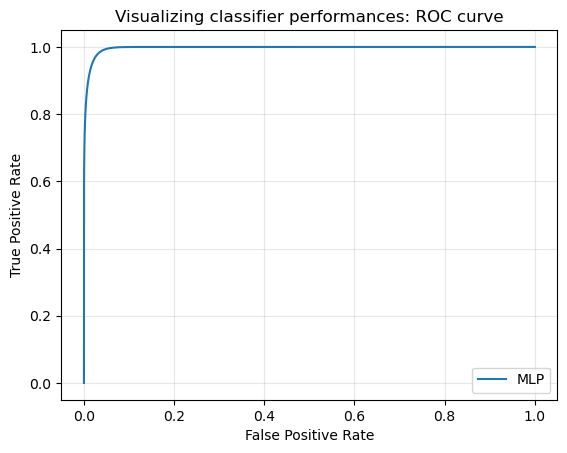

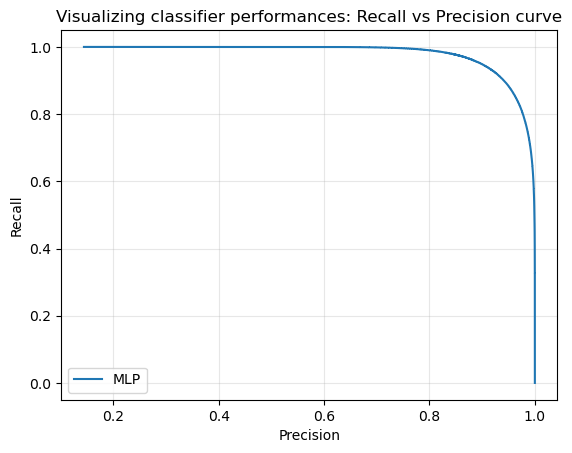

In [ ]:
# Plotting performances
plt.plot(fpr_mlp, tpr_mlp, label="MLP")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
plt.close()

plt.plot(precision_mlp, recall_mlp, label="MLP")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
report_dict = classification_report(y_test, y_pred_mlp, output_dict=True)
accuracy = report_dict.pop('accuracy')
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(3)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.978


In [ ]:
df_report

,precision,recall,f1-score,support
0.0,0.986,0.989,0.987,5134533.0
1.0,0.931,0.916,0.923,865467.0
macro avg,0.958,0.952,0.955,6000000.0
weighted avg,0.978,0.978,0.978,6000000.0


#### PyTorch (run on Google Colab)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [15]:
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA runtime version:", torch.version.cuda)

GPU name: Tesla T4
CUDA runtime version: 12.6


In [16]:
# Computational speed test
size = (10000, 10000)

# --- Test CPU ---
x_cpu = torch.randn(size)
y_cpu = torch.randn(size)

start_cpu = time.time()
z_cpu = x_cpu @ y_cpu  # Matrix product
torch.cuda.synchronize() if torch.cuda.is_available() else None
end_cpu = time.time()
print(f"CPU: {end_cpu - start_cpu:.4f} s")

# --- Test GPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    x_gpu = x_cpu.to(device)
    y_gpu = y_cpu.to(device)

    torch.cuda.synchronize()
    start_gpu = time.time()
    z_gpu = x_gpu @ y_gpu
    torch.cuda.synchronize()
    end_gpu = time.time()
    print(f"GPU: {end_gpu - start_gpu:.4f} s")
else:
    print("No GPU available")

CPU: 35.4768 s
GPU: 0.8090 s


In [17]:
# Let's downsample the data since there isn't enough RAM memory
sel_table = table.sample(frac=0.1, random_state=123)

In [18]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [19]:
# Formatting data with the sklearn style
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [20]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(2000000, 13)
(2000000,)


In [21]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [22]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [23]:
print(X_std_train.shape)
print(y_train.shape)
print(X_std_test.shape)
print(y_test.shape)

(1400000, 13)
(1400000,)
(600000, 13)
(600000,)


In [24]:
# Now convert datasets into PyTorch tensors
X_train_tensor = torch.tensor(X_std_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor = torch.tensor(X_std_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [25]:
# Loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [26]:
# Creating a validation subset for the early stopping procedure
full_dataset = train_loader.dataset
val_fraction = 0.2
val_size = int(len(full_dataset) * val_fraction)
train_size = len(full_dataset) - val_size
gen = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)

In [27]:
# The autoencoder learns to reconstruct inputs and produce compressed latent features
n_lat = 9
class Autoencoder(nn.Module):
    def __init__(self, input_dim=13, latent_dim=n_lat):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10),
            nn.ReLU(),
            nn.Linear(10, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [28]:
# Initialization
autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.01, weight_decay=0.01)

# Early Stopping Parameters
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(200):
    # ----- TRAINING -----
    autoencoder.train()
    total_train_loss = 0
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        recon = autoencoder(X_batch)
        loss = criterion(recon, X_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    # ----- VALIDATION -----
    autoencoder.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_val, _ in val_loader:
            X_val = X_val.to(device)
            recon_val = autoencoder(X_val)
            val_loss = criterion(recon_val, X_val)
            total_val_loss += val_loss.item()
    avg_val_loss = total_val_loss / len(val_loader)

    # Log
    print(f"Epoch [{epoch+1}/200] - Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # ----- EARLY STOPPING -----
    if avg_val_loss < best_val_loss*(1-1e-3):
        best_val_loss = avg_val_loss
        counter = 0
        best_model_wts = autoencoder.state_dict()  # Save best weights
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Reload best weights
autoencoder.load_state_dict(best_model_wts)

Epoch [1/200] - Train Loss: 0.384277 | Val Loss: 0.337145
Epoch [2/200] - Train Loss: 0.335797 | Val Loss: 0.335645
Epoch [3/200] - Train Loss: 0.335494 | Val Loss: 0.337261
Epoch [4/200] - Train Loss: 0.335672 | Val Loss: 0.336110
Epoch [5/200] - Train Loss: 0.335673 | Val Loss: 0.336748
Epoch [6/200] - Train Loss: 0.335678 | Val Loss: 0.335881
Epoch [7/200] - Train Loss: 0.335587 | Val Loss: 0.336424
Epoch [8/200] - Train Loss: 0.335597 | Val Loss: 0.335011
Epoch [9/200] - Train Loss: 0.335638 | Val Loss: 0.336126
Epoch [10/200] - Train Loss: 0.335574 | Val Loss: 0.337738
Epoch [11/200] - Train Loss: 0.335645 | Val Loss: 0.336448
Epoch [12/200] - Train Loss: 0.335558 | Val Loss: 0.334468
Epoch [13/200] - Train Loss: 0.335640 | Val Loss: 0.335624
Epoch [14/200] - Train Loss: 0.335532 | Val Loss: 0.337003
Epoch [15/200] - Train Loss: 0.335642 | Val Loss: 0.334715
Epoch [16/200] - Train Loss: 0.335639 | Val Loss: 0.336719
Epoch [17/200] - Train Loss: 0.335569 | Val Loss: 0.335442
Epoch 

<All keys matched successfully>

In [29]:
autoencoder.eval()
with torch.no_grad():
    X_train_latent = autoencoder.encoder(X_train_tensor.to(device)).cpu()
    X_test_latent  = autoencoder.encoder(X_test_tensor.to(device)).cpu()

In [30]:
print(X_train_latent.shape)
print(X_test_latent.shape)

torch.Size([1400000, 9])
torch.Size([600000, 9])


In [31]:
# Convert to numpy for some visualization
X_torch = X_test_latent.cpu().numpy()
y_true_torch = y_test_tensor.cpu().numpy()

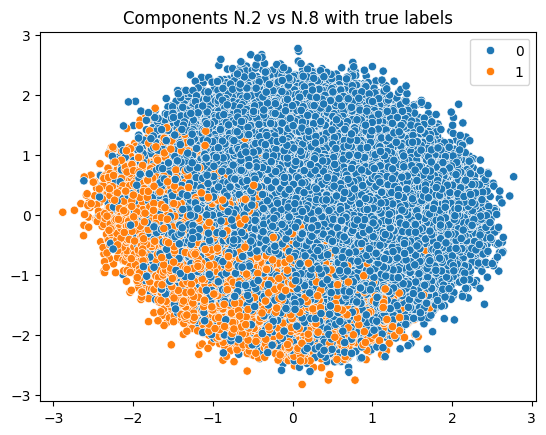

In [33]:
i, j = np.random.choice(range(n_lat), 2, replace=False)
sns.scatterplot(x=X_torch[:, i], y=X_torch[:, j], hue=y_true_torch)
plt.title(f"Components N.{i} vs N.{j} with true labels")
plt.show()
plt.close()

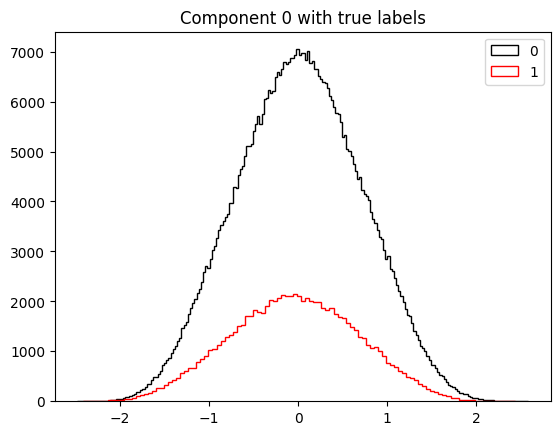

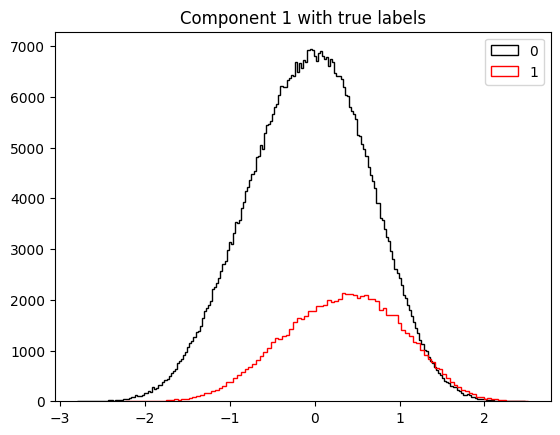

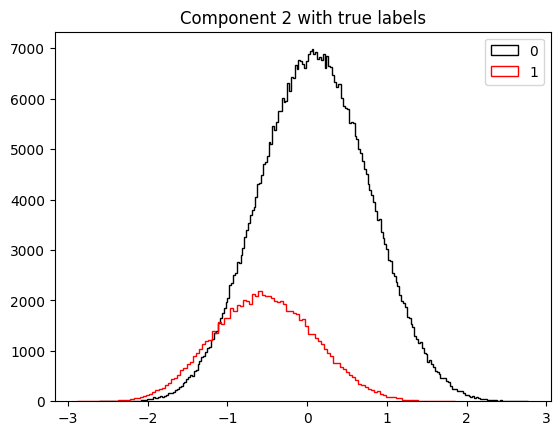

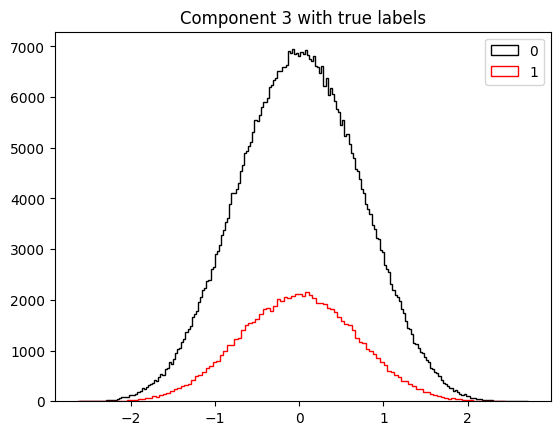

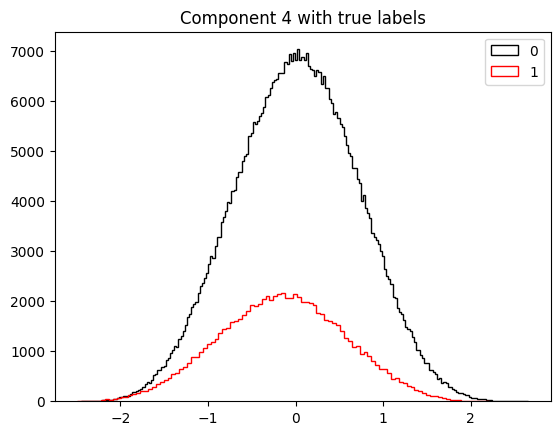

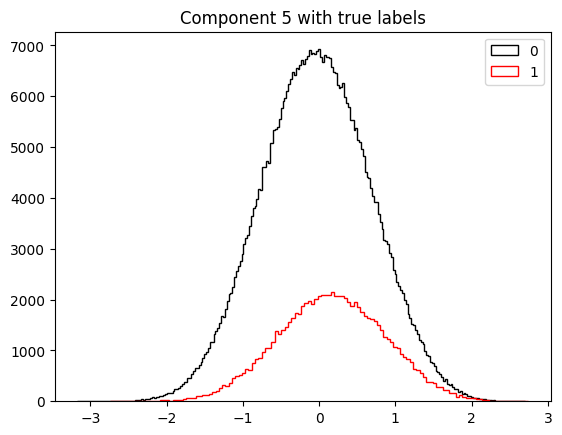

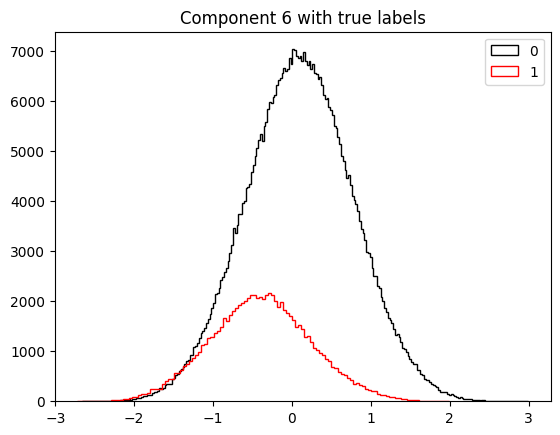

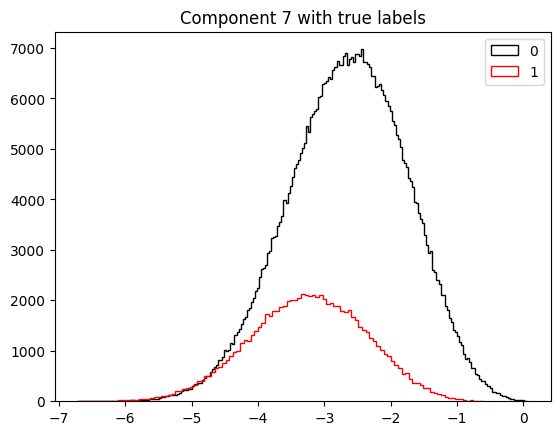

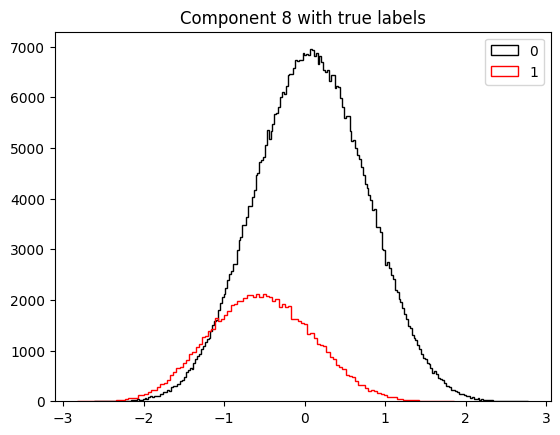

In [34]:
for i in range(n_lat):
  plt.hist(X_torch[:, i].flatten()[y_true_torch==0], bins="auto", histtype='step', color='black', label="0")
  plt.hist(X_torch[:, i].flatten()[y_true_torch==1], bins="auto", histtype='step', color='red', label="1")
  plt.legend()
  plt.title(f"Component {i} with true labels")
  plt.show()
  plt.close()

In [35]:
# Now train a fully-connected neural network (a MLP) with the reduced dataset
class MLP(nn.Module):
    def __init__(self, input_dim=n_lat):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 10),
            nn.ReLU(),
            nn.Linear(10, 2)  # 2 logit → CrossEntropyLoss
        )

    def forward(self, x):
        return self.net(x)

In [36]:
# Creating a validation subset for the early stopping procedure
train_latent_loader = DataLoader(TensorDataset(X_train_latent, y_train_tensor), batch_size=128, shuffle=True)
full_dataset_latent = train_latent_loader.dataset

val_fraction = 0.2
val_size = int(len(full_dataset_latent) * val_fraction)
train_size = len(full_dataset_latent) - val_size

train_latent_subset, val_latent_subset = random_split(full_dataset_latent, [train_size, val_size], generator=gen)

train_latent_loader = DataLoader(train_latent_subset, batch_size=128, shuffle=True)
val_latent_loader = DataLoader(val_latent_subset, batch_size=128, shuffle=False)


In [37]:
# Initialization
mlp_torch = MLP().to(device)
criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp_torch.parameters(), lr=0.01, weight_decay=0.01)

# Early Stopping Parameters
patience = 10
best_val_loss_mlp = float('inf')
counter = 0

for epoch in range(200):
    # ----- TRAINING -----
    mlp_torch.train()
    total_train_loss_mlp = 0
    for X_batch, y_batch in train_latent_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_mlp.zero_grad()
        outputs_mlp = mlp_torch(X_batch)
        loss_mlp = criterion_mlp(outputs_mlp, y_batch)
        loss_mlp.backward()
        optimizer_mlp.step()
        total_train_loss_mlp += loss_mlp.item()
    avg_train_loss_mlp = total_train_loss_mlp / len(train_latent_loader)

    # ----- VALIDATION -----
    mlp_torch.eval()
    total_val_loss_mlp = 0
    with torch.no_grad():
        for X_val, y_val in val_latent_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = mlp_torch(X_val)
            val_loss_mlp = criterion_mlp(outputs_val, y_val)
            total_val_loss_mlp += val_loss_mlp.item()
    avg_val_loss_mlp = total_val_loss_mlp / len(val_latent_loader)

    # Log
    print(f"Epoch [{epoch+1}/200] - Train Loss: {avg_train_loss_mlp:.6f} | Val Loss: {avg_val_loss_mlp:.6f}")

    # ----- EARLY STOPPING -----
    if avg_val_loss_mlp < best_val_loss_mlp*(1-1e-3):
        best_val_loss_mlp = avg_val_loss_mlp
        counter = 0
        best_model_mlp = mlp_torch.state_dict()  # Save best weights
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Reload best weights
mlp_torch.load_state_dict(best_model_mlp)

Epoch [1/200] - Train Loss: 0.143809 | Val Loss: 0.137836
Epoch [2/200] - Train Loss: 0.140013 | Val Loss: 0.151308
Epoch [3/200] - Train Loss: 0.139535 | Val Loss: 0.149070
Epoch [4/200] - Train Loss: 0.139548 | Val Loss: 0.140025
Epoch [5/200] - Train Loss: 0.139642 | Val Loss: 0.139980
Epoch [6/200] - Train Loss: 0.139628 | Val Loss: 0.137531
Epoch [7/200] - Train Loss: 0.139485 | Val Loss: 0.138695
Epoch [8/200] - Train Loss: 0.139464 | Val Loss: 0.139147
Epoch [9/200] - Train Loss: 0.139534 | Val Loss: 0.138512
Epoch [10/200] - Train Loss: 0.139531 | Val Loss: 0.135409
Epoch [11/200] - Train Loss: 0.139408 | Val Loss: 0.136065
Epoch [12/200] - Train Loss: 0.139508 | Val Loss: 0.136815
Epoch [13/200] - Train Loss: 0.139617 | Val Loss: 0.138817
Epoch [14/200] - Train Loss: 0.139759 | Val Loss: 0.137512
Epoch [15/200] - Train Loss: 0.139400 | Val Loss: 0.138306
Epoch [16/200] - Train Loss: 0.139601 | Val Loss: 0.138384
Epoch [17/200] - Train Loss: 0.139420 | Val Loss: 0.135839
Epoch 

<All keys matched successfully>

In [38]:
mlp_torch.eval()
with torch.no_grad():
    outs = mlp_torch(X_test_latent.to(device))
    preds = torch.argmax(outs, dim=1).cpu()
    probs = torch.softmax(outs, dim=1)[:, 1].cpu()

# Convert to numpy
y_pred_torch = preds.numpy()
y_prob_torch = probs.numpy()

# Metrics
acc = accuracy_score(y_true_torch, y_pred_torch)
prec = precision_score(y_true_torch, y_pred_torch)
rec = recall_score(y_true_torch, y_pred_torch)
cont = 1 - prec

# Print results
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"Contamination: {cont:.3f}")

Accuracy:  0.945
Precision: 0.793
Recall:    0.835
Contamination: 0.207


In [39]:
fpr_mlp, tpr_mlp, thresh1_mlp = roc_curve(y_true_torch, y_prob_torch)
precision_mlp, recall_mlp, thresh2_mlp = precision_recall_curve(y_true_torch, y_prob_torch)

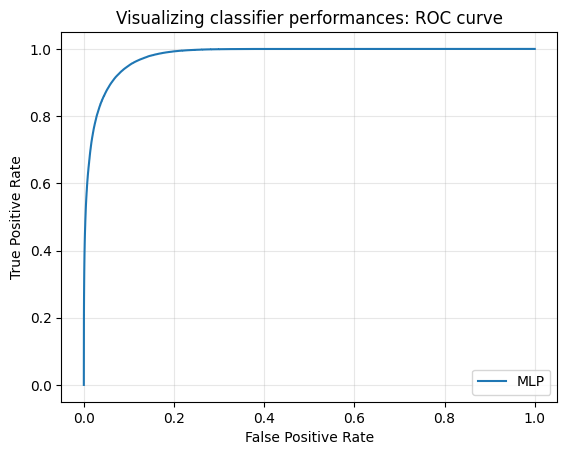

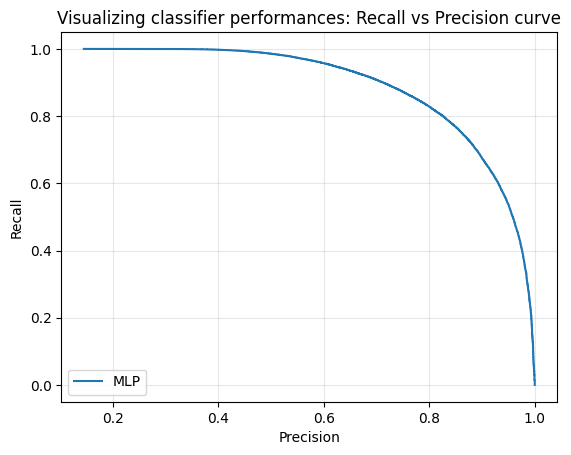

In [40]:
# Plotting performances
plt.plot(fpr_mlp, tpr_mlp, label="MLP")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
plt.close()

plt.plot(precision_mlp, recall_mlp, label="MLP")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [41]:
report_dict = classification_report(y_true_torch, y_pred_torch, output_dict=True)
accuracy = report_dict.pop('accuracy')
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(3)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.945


In [42]:
df_report

,precision,recall,f1-score,support
0,0.972,0.963,0.968,513292.0
1,0.793,0.835,0.814,86708.0
macro avg,0.883,0.899,0.891,600000.0
weighted avg,0.946,0.945,0.945,600000.0


Reducing the dimensionality of the dataset doesn't seem to bring big improvements for the classification task